In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
import os
import numpy as np
import joblib
from scipy.stats import skew

from utils.evaluation import plot_density
from utils.load_data import load_data

import torch
import torch.nn as nn

In [40]:
data_path = '../data/cancer_reg-1.csv'
df = load_data(data_path)

### Drop PctSomeCol18_24 column since it contains missing values of more than 70% of the dataset


In [41]:
df = df.drop(columns=['PctSomeCol18_24'])

### Drop rows having MedianAge > 120 having missing values and modify remaining without missing values with the median

In [42]:
# df = df[~(df['MedianAge'] > 120)].copy()
# df.loc[df['MedianAge'] > 120, 'MedianAge'] = df['MedianAge'].median()
df.loc[df['MedianAge'] > 120, 'MedianAge'] = df['MedianAge'] / 10

### Impute PctPrivateCoverageAlone(20% missing values) and PctEmployed16_Over(5% missing values) with the median

In [43]:
df['PctPrivateCoverageAlone'] = df['PctPrivateCoverageAlone'].fillna(df['PctPrivateCoverageAlone'].median())
df['PctEmployed16_Over'] = df['PctEmployed16_Over'].fillna(df['PctEmployed16_Over'].median())

In [44]:
df.isna().sum().sort_values(ascending=False)

avgAnnCount                0
PctBachDeg18_24            0
PctMarriedHouseholds       0
PctOtherRace               0
PctAsian                   0
PctBlack                   0
PctWhite                   0
PctPublicCoverageAlone     0
PctPublicCoverage          0
PctEmpPrivCoverage         0
PctPrivateCoverageAlone    0
PctPrivateCoverage         0
PctUnemployed16_Over       0
PctEmployed16_Over         0
PctBachDeg25_Over          0
PctHS25_Over               0
PctHS18_24                 0
avgDeathsPerYear           0
PctNoHS18_24               0
PercentMarried             0
AvgHouseholdSize           0
Geography                  0
MedianAgeFemale            0
MedianAgeMale              0
MedianAge                  0
binnedInc                  0
studyPerCap                0
povertyPercent             0
popEst2015                 0
medIncome                  0
incidenceRate              0
TARGET_deathRate           0
BirthRate                  0
dtype: int64

Now the numerial features don't have missing values anymore

### Handle categorical values

In [45]:
df[['Geography']]

,Geography
0,"Kitsap County, Washington"
1,"Kittitas County, Washington"
2,"Klickitat County, Washington"
3,"Lewis County, Washington"
4,"Lincoln County, Washington"
...,...
3042,"Ellsworth County, Kansas"
3043,"Finney County, Kansas"
3044,"Ford County, Kansas"
3045,"Franklin County, Kansas"


In [46]:
df[['binnedInc', 'Geography']]

,binnedInc,Geography
0,"(61494.5, 125635]","Kitsap County, Washington"
1,"(48021.6, 51046.4]","Kittitas County, Washington"
2,"(48021.6, 51046.4]","Klickitat County, Washington"
3,"(42724.4, 45201]","Lewis County, Washington"
4,"(48021.6, 51046.4]","Lincoln County, Washington"
...,...,...
3042,"(45201, 48021.6]","Ellsworth County, Kansas"
3043,"(48021.6, 51046.4]","Finney County, Kansas"
3044,"(51046.4, 54545.6]","Ford County, Kansas"
3045,"(48021.6, 51046.4]","Franklin County, Kansas"


For `binnedInc`, we transforms it into the mean, lower, and upper values since they can be valuable rather than just the `medIncome` alone (median income)

In [47]:
def compute_mean(bin_income):
    """Compute the mean of a string like '(5000, 20000]'"""
    bin_income = bin_income.strip('()[]')
    lower, upper = bin_income.split(',')
    lower, upper = float(lower), float(upper)
    return (lower + upper) / 2, lower, upper

df['meanIncome'], df['lowerIncome'], df['upperIncome'] = zip(*df['binnedInc'].apply(compute_mean))
df = df.drop(columns=['binnedInc'], axis=1)

In [48]:
df[['Geography']].describe()

,Geography
count,3047
unique,3047
top,"Kitsap County, Washington"
freq,1


For `Geography`, since all values are unique, we can safely remove this feature since encoding it won't provide valuable information and method like one hot encoding will create a giant sparse matrix

In [49]:
# states = df['Geography'].apply(lambda x: x.split(',')[-1].strip())
# counties = df['Geography'].apply(lambda x: x.split(',')[0].strip())

# state_emb = LabelEncoder().fit_transform(states)
# state_emb = nn.Embedding(len(np.unique(state_emb)), 8)(torch.tensor(state_emb))
# county_emb = LabelEncoder().fit_transform(counties)
# county_emb = nn.Embedding(len(np.unique(county_emb)), 4)(torch.tensor(county_emb))

# geo_emb = torch.cat([state_emb, county_emb], dim=1).detach().numpy()
# geo_feats = pd.DataFrame(geo_emb, columns=[f'geo_emb_{i}' for i in range(geo_emb.shape[1])])
# df = pd.concat([df, geo_feats], axis=1)

df = df.drop(columns=['Geography'], axis=1)

### Handle skewness

#### Apply log transform for right-skewed data

In [50]:
num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
skewed_feats = df[num_features].apply(lambda x: skew(x.dropna()))
right_skewed_feats = skewed_feats[skewed_feats > 1.0].index
right_skewed_feats

Index(['avgAnnCount', 'avgDeathsPerYear', 'medIncome', 'popEst2015',
       'studyPerCap', 'PctBachDeg18_24', 'PctBachDeg25_Over', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'BirthRate', 'meanIncome', 'upperIncome'],
      dtype='object')

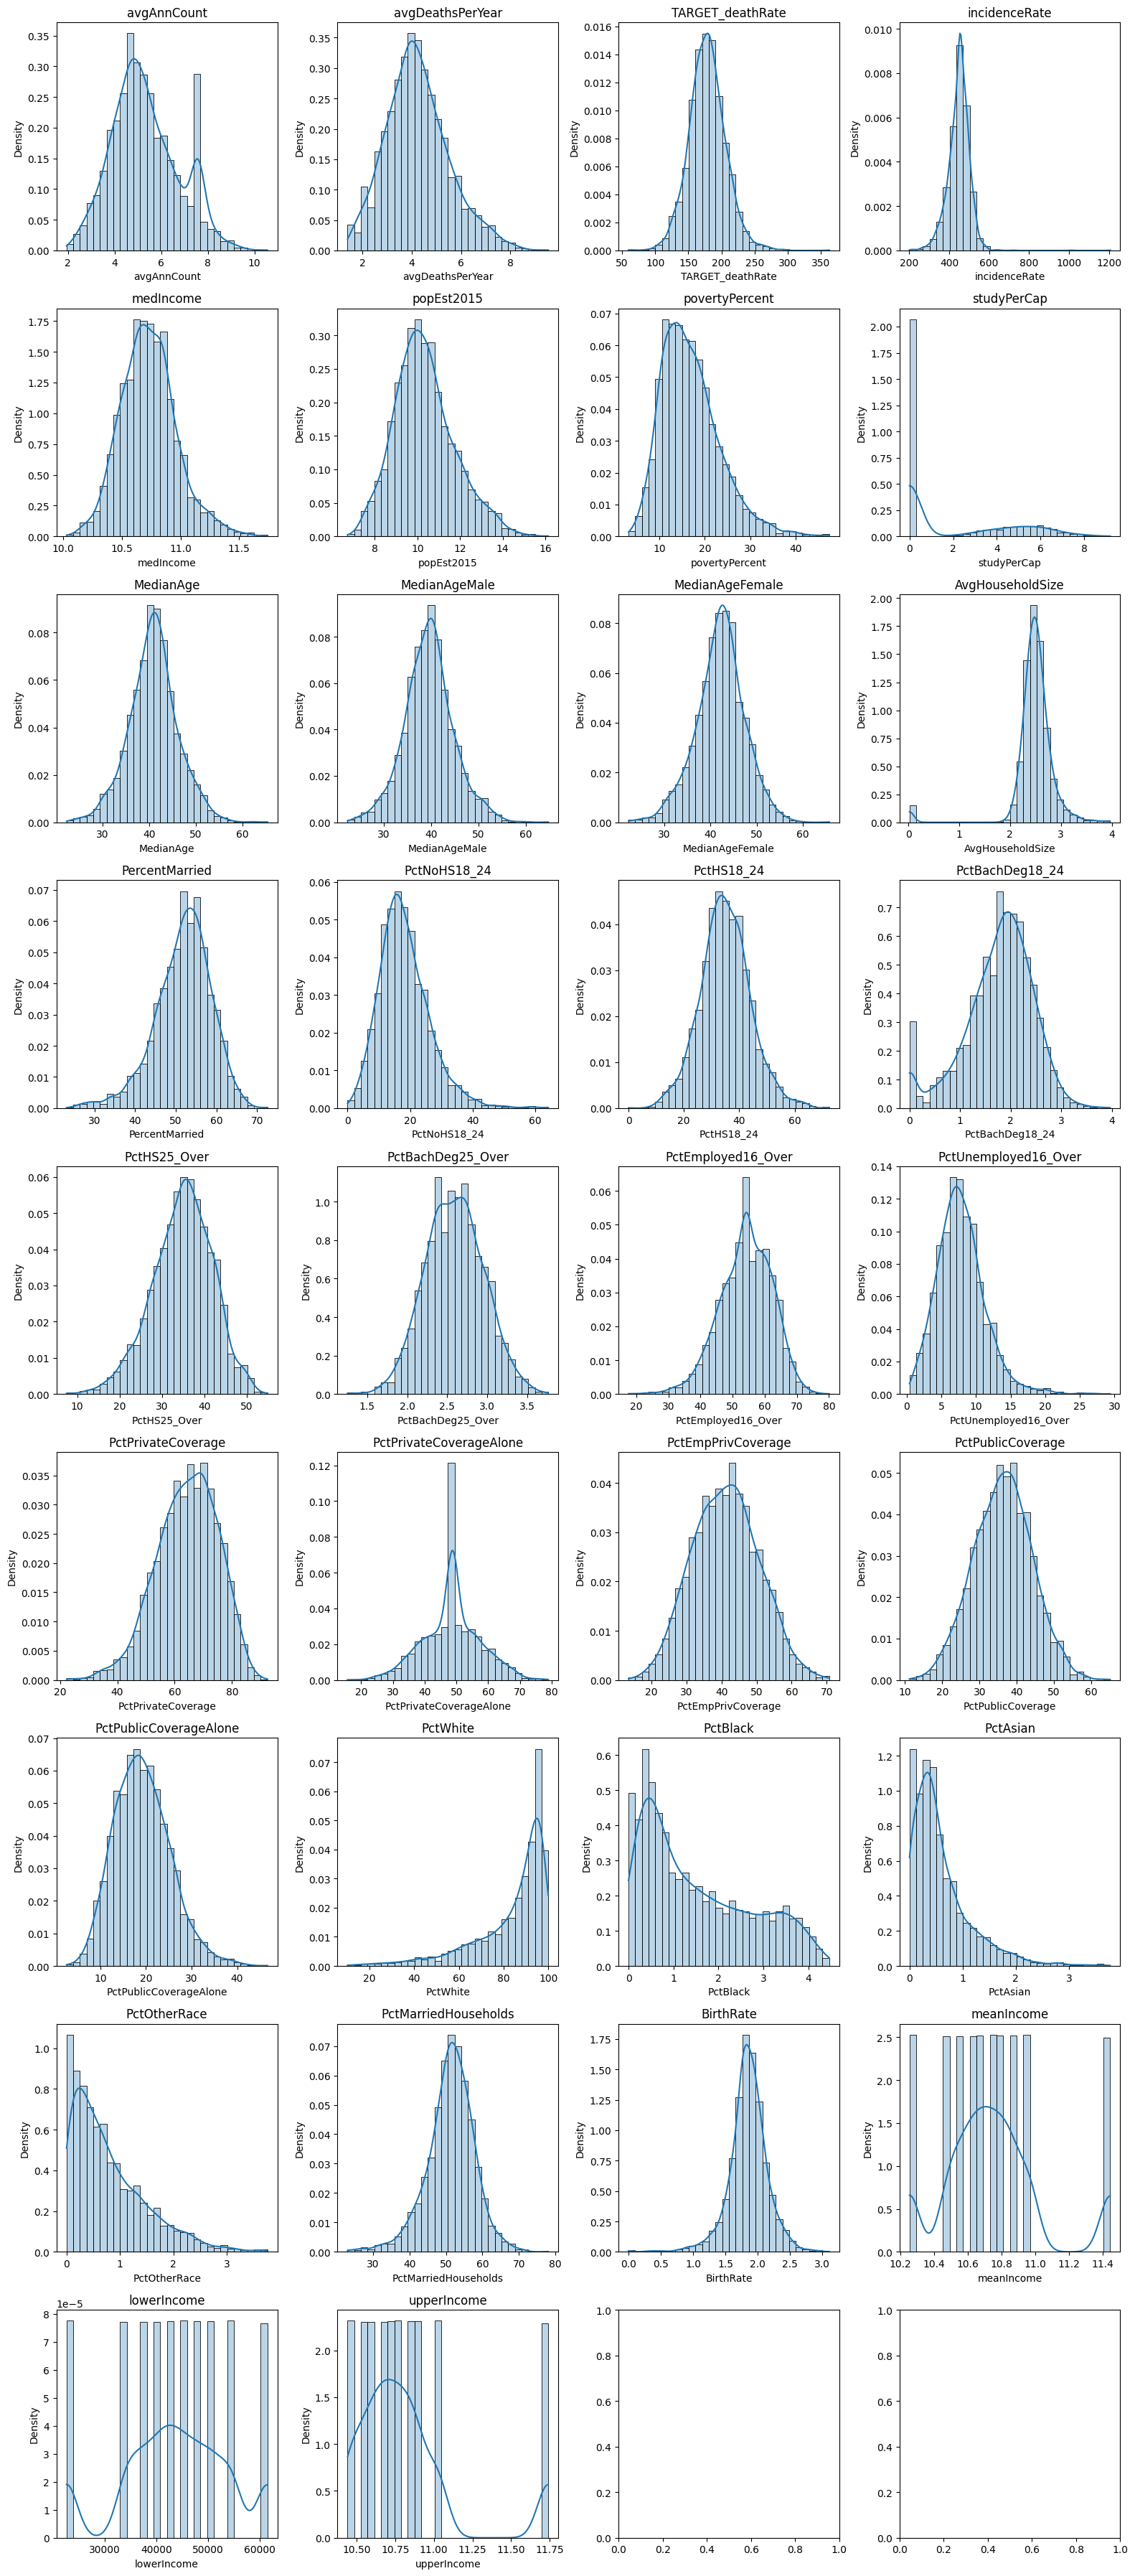

In [51]:
df[right_skewed_feats] = np.log1p(df[right_skewed_feats])
plot_density(df, 4)

### Split dataset

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   float64
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   float64
 5   popEst2015               3047 non-null   float64
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   MedianAge                3047 non-null   float64
 9   MedianAgeMale            3047 non-null   float64
 10  MedianAgeFemale          3047 non-null   float64
 11  AvgHouseholdSize         3047 non-null   float64
 12  PercentMarried           3047 non-null   float64
 13  PctNoHS18_24             3047 non-null   float64
 14  PctHS18_24              

Now, all the features are numerical and don't contain any missing values, we can split our dataset for training

In [53]:
train_test_ratio = 0.7
val_test_ratio = 0.5
seed = 2025

X = df.drop(columns=['TARGET_deathRate'], axis=1)
y = df['TARGET_deathRate']

X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, train_size=train_test_ratio, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=val_test_ratio, random_state=seed)

#### Normalize

Note that we scale **after** splitting to avoid data leakage

In [54]:
scaler = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# y_scaler = MinMaxScaler()
# y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_val = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
# y_test = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

# joblib.dump(y_scaler, '../models/y_scaler.pkl')

#### Shape of splitted data

In [55]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (2132, 33), y_train: (2132,)
X_val: (457, 33), y_val: (457,)
X_test: (458, 33), y_test: (458,)


### Save data for later training and evaluation

In [56]:
!rm -rf ../data/processed

In [57]:
save_path = '../data/processed/'
os.makedirs(save_path, exist_ok=True)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_val = pd.DataFrame(X_val, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
y_train = pd.DataFrame(y_train, columns=['TARGET_deathRate'])
y_val = pd.DataFrame(y_val, columns=['TARGET_deathRate'])
y_test = pd.DataFrame(y_test, columns=['TARGET_deathRate'])

X_train.to_csv(f'{save_path}X_train.csv', index=False)
X_val.to_csv(f'{save_path}X_val.csv', index=False)
X_test.to_csv(f'{save_path}X_test.csv', index=False)

y_train.to_csv(f'{save_path}y_train.csv', index=False)
y_val.to_csv(f'{save_path}y_val.csv', index=False)
y_test.to_csv(f'{save_path}y_test.csv', index=False)